In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [14]:
# Cell 2 — Parameters
# Path to your input file (two columns: barcode, count; no header)
INPUT_TSV = '/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/scratch/P0/counts_P0.tsv'

# Output file for the filtered results
OUTPUT_TSV = '/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/scratch/P0/counts_P0_e5_FLU.tsv'

# Frequency threshold; barcodes with frequency <= this value are REMOVED
FREQ_THRESHOLD = 1e-5

In [15]:
# Cell 3 — Load the TSV (barcode\tcount)
# We accept any whitespace between columns and ignore lines starting with '#'
# The file should have NO header row.
df = pd.read_csv(
    INPUT_TSV,
    sep=r'\s+',
    header=None,
    names=['barcode', 'count'],
    engine='python',
    comment='#'
)

# Clean up types
df['barcode'] = df['barcode'].astype(str).str.strip()
df['count'] = pd.to_numeric(df['count'], errors='coerce')

# Drop rows where barcode is missing/empty or count is NaN
df = df[df['barcode'].str.len() > 0].copy()
df = df.dropna(subset=['count']).copy()

print(f"Loaded {len(df):,} rows from {INPUT_TSV}")
df.head()

Loaded 88,140 rows from /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/scratch/P0/counts_P0.tsv


,barcode,count
0,AAAAAAAACAAACGGAATTATAGCATGTGGAA,584.0
1,AAAAAAAACAAACGGATCACTATTCGTAAAGA,2802.0
2,AAAAAAAACTTGGAAAATTACTATTAAACAAG,2324.0
3,AAAAAAAACTTGGAAATGTCAAGGCTAACGAG,178.0
4,AAAAAAAAGTGATGGAACGAAGTCAGTTCTCA,248.0


In [16]:
# Cell 4 — Normalize to frequency
total_counts = df['count'].sum()

if total_counts == 0:
    raise ValueError("Total counts sum to zero — cannot compute frequencies. Check your input.")

df['frequency'] = df['count'] / total_counts
print(f"Total counts: {total_counts:.6f}")
df.head()

Total counts: 156570819.000000


,barcode,count,frequency
0,AAAAAAAACAAACGGAATTATAGCATGTGGAA,584.0,0.000004
1,AAAAAAAACAAACGGATCACTATTCGTAAAGA,2802.0,0.000018
2,AAAAAAAACTTGGAAAATTACTATTAAACAAG,2324.0,0.000015
3,AAAAAAAACTTGGAAATGTCAAGGCTAACGAG,178.0,0.000001
4,AAAAAAAAGTGATGGAACGAAGTCAGTTCTCA,248.0,0.000002


In [17]:
# Cell 5 — Filter out barcodes with frequency <= threshold
before = len(df)
filtered = df[df['frequency'] > FREQ_THRESHOLD].copy()
after = len(filtered)
removed = before - after
print(f"Kept {after:,} / {before:,} barcodes (removed {removed:,}).")
print(f"Threshold used: frequency > {FREQ_THRESHOLD:g}")

filtered.head()

Kept 27,701 / 88,140 barcodes (removed 60,439).
Threshold used: frequency > 1e-05


,barcode,count,frequency
1,AAAAAAAACAAACGGATCACTATTCGTAAAGA,2802.0,0.000018
2,AAAAAAAACTTGGAAAATTACTATTAAACAAG,2324.0,0.000015
5,AAAAAAAAGTGATGGAATATGACAAGTATTGG,5835.0,0.000037
10,AAAAAAAGAAGATTTATGAACGGCCCTAATGG,3062.0,0.000020
13,AAAAAAAGTCTTGAGGTAAAACCGGAGCGCCA,1773.0,0.000011


In [18]:
# Cell 6 — Save the filtered table to TSV (barcode + count only, NO HEADER)
filtered[['barcode', 'count']].to_csv(OUTPUT_TSV, sep='\t', index=False, header=False)
print(f"Saved filtered results to: {OUTPUT_TSV} (2 columns: barcode, count; no header)")

Saved filtered results to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/scratch/P0/counts_P0_e5_FLU.tsv (2 columns: barcode, count; no header)


In [19]:
# Cell 7 — Optional: quick summary stats
summary = {
    'n_input': len(df),
    'n_kept': len(filtered),
    'n_removed': len(df) - len(filtered),
    'min_frequency_kept': float(filtered['frequency'].min()) if len(filtered) else None,
    'max_frequency_kept': float(filtered['frequency'].max()) if len(filtered) else None,
    'sum_frequency_kept': float(filtered['frequency'].sum()) if len(filtered) else 0.0,
}
summary

{'n_input': 88140,
 'n_kept': 27701,
 'n_removed': 60439,
 'min_frequency_kept': 1.000186375725607e-05,
 'max_frequency_kept': 0.0009265008698715435,
 'sum_frequency_kept': 0.7896348488794711}

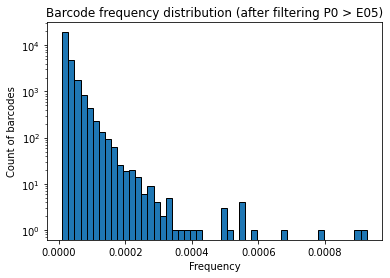

In [20]:
# Cell 8 — Visualize frequency distribution histogram
plt.figure(figsize=(6,4))
plt.hist(filtered['frequency'], bins=50, edgecolor='black')
plt.xlabel("Frequency")
plt.ylabel("Count of barcodes")
plt.title("Barcode frequency distribution (after filtering P0 > E05)")
plt.yscale("log")   # use log scale to show rare & common barcodes
plt.show()